# Tier 2: Parameter Recovery Validation

**Purpose:** Determine whether CTDS EM is a *consistent estimator* — one that recovers the true parameters as data grows, with no systematic bias, and degrades gracefully under noise.

Three experiments:
- **Exp 2.1** — Recovery vs. sample size (T and B sweeps); tests O(1/√TB) convergence rate
- **Exp 2.2** — Scatter plots of true vs. recovered entries; tests for bias
- **Exp 2.3** — Recovery vs. SNR; tests graceful degradation

There is **no LDS baseline** here. The question is purely about CTDS EM properties.

## Section 0: Imports and Global Configuration

All experiment hyperparameters are defined here as named constants. Change them here, not inline.

In [1]:
# ============================================================
# Standard imports
# ============================================================
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import scipy.linalg
from scipy.optimize import linear_sum_assignment
from scipy.stats import linregress
from tqdm import tqdm

import jax
import jax.numpy as jnp
import jax.random as jr

jax.config.update("jax_enable_x64", True)

# ============================================================
# Project imports  — adjust paths to match your repo layout
# ============================================================
# from your_package.params import ParamsCTDS, ParamsCTDSConstraints, ...
# from your_package.models import CTDS
# from your_package.simulation_utils import generate_CTDS_Params, make_A_true, make_Q_true
# from your_package.models import _gauge_fix_clamped, _psd_project

# ============================================================
# Architecture constants (fixed for ALL experiments)
# ============================================================
D   = 4    # total latent dims
D_E = 2    # excitatory latents
D_I = 2    # inhibitory latents
N   = 20   # total neurons
N_E = 14   # excitatory neurons
N_I = 6    # inhibitory neurons

# ============================================================
# Exp 2.1 — sample-size sweep
# ============================================================
T_VALUES = [100, 500, 1000, 5000]   # vary T, fix B=1
B_VALUES = [1, 5, 20]               # vary B, fix T=500
N_SEEDS  = 10                       # independent datasets per condition

# ============================================================
# Exp 2.2 — scatter plots
# ============================================================
SCATTER_T_HIGH = 1000;  SCATTER_B_HIGH = 20   # high-data condition
SCATTER_T_LOW  = 100;   SCATTER_B_LOW  = 1    # low-data condition

# ============================================================
# Exp 2.3 — SNR sweep
# Q_alpha = alpha * Q_true,  R_alpha = (1/alpha) * R_true
# alpha < 1  →  low SNR;   alpha > 1  →  high SNR
# ============================================================
SNR_ALPHAS  = [0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 2.0, 5.0, 10.0]
SNR_T, SNR_B = 500, 5
SNR_T_TEST   = 500   # held-out trials for LL evaluation
SNR_B_TEST   = 20

# ============================================================
# EM settings
# ============================================================
N_EM_ITERS = 150

# ============================================================
# Caching — set USE_CACHE=True after first run
# ============================================================
USE_CACHE  = False
CACHE_DIR  = "./tier2_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

MASTER_KEY = jr.PRNGKey(42)

# ============================================================
# Plot style
# ============================================================
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "figure.dpi": 120,
})
BLUE   = "#2166AC"
ORANGE = "#D6604D"
GREEN  = "#4DAC26"
PURPLE = "#762A83"
GRAY   = "#888888"

print("Configuration loaded.")
print(f"D={D} (D_E={D_E}, D_I={D_I})  |  N={N} (N_E={N_E}, N_I={N_I})")
print(f"USE_CACHE={USE_CACHE}")

Configuration loaded.
D=4 (D_E=2, D_I=2)  |  N=20 (N_E=14, N_I=6)
USE_CACHE=False


## Section 1: Canonical True Parameter Set

A single fixed ground-truth CTDS is used for every experiment. All variation across experiments is due to data quantity or noise level, not parameter variation.

In [2]:
# ============================================================
# 1.1  Generate the canonical true parameters
# ============================================================
TRUE_KEY = jr.PRNGKey(0)

# Build cell-type constraint arrays
cell_types           = jnp.array([0, 1])           # two cell types
cell_sign            = jnp.array([1, -1])           # E=+1, I=-1
cell_type_dimensions = jnp.array([D_E, D_I])        # latent dims per type
cell_type_mask       = jnp.array(
    [0]*N_E + [1]*N_I, dtype=jnp.int32
)                                                   # neuron → cell type
dynamics_mask        = jnp.array(
    [1]*D_E + [-1]*D_I, dtype=jnp.int32
)                                                   # latent → sign

# ----- Generate true parameters using your existing utilities -----
# Replace the lines below with your actual calls once imports are set up.
# params_true = generate_CTDS_Params(
#     N=N, D=D, K=2,
#     cell_types=cell_types, cell_sign=cell_sign,
#     cell_type_dimensions=cell_type_dimensions,
#     cell_type_mask=cell_type_mask,
#     seed=TRUE_KEY
# )

# ---- STUB — replace with real params once imports are active ----
# The stub creates syntactically correct arrays so the rest of the
# notebook parses. Delete / replace when running for real.
import numpy as _np
_np.random.seed(0)

def _stub_make_A(D_E, D_I, rho=0.92):
    D = D_E + D_I
    A = _np.zeros((D, D))
    # EE block (cols 0:D_E) — off-diag positive
    for j in range(D_E):
        for i in range(D):
            if i == j:
                A[i, j] = _np.random.uniform(0.3, 0.7)
            else:
                A[i, j] = _np.random.uniform(0.0, 0.3)
    # II block (cols D_E:D) — off-diag negative
    for j in range(D_E, D):
        for i in range(D):
            if i == j:
                A[i, j] = _np.random.uniform(0.3, 0.7)
            else:
                A[i, j] = -_np.random.uniform(0.0, 0.3)
    # Scale to spectral radius rho
    sr = _np.max(_np.abs(_np.linalg.eigvals(A)))
    A = A * (rho / sr)
    return jnp.array(A)

def _stub_make_C(N_E, N_I, D_E, D_I):
    C = _np.zeros((N_E + N_I, D_E + D_I))
    C[:N_E, :D_E] = _np.random.uniform(0.2, 1.0, (N_E, D_E))
    C[N_E:, D_E:] = _np.random.uniform(0.2, 1.0, (N_I, D_I))
    return jnp.array(C)

A_true = _stub_make_A(D_E, D_I)
C_true = _stub_make_C(N_E, N_I, D_E, D_I)
Q_true = jnp.array(_np.eye(D) * 0.005 + _np.abs(_np.random.randn(D, D)) * 0.001)
Q_true = (Q_true + Q_true.T) / 2
R_true = jnp.diag(jnp.array(_np.random.uniform(0.05, 0.2, N)))

# ---------------------------------------------------------------

print("True parameter shapes:")
print(f"  A_true: {A_true.shape}")
print(f"  C_true: {C_true.shape}")
print(f"  Q_true: {Q_true.shape}")
print(f"  R_true: {R_true.shape}")

sr = float(jnp.max(jnp.abs(jnp.linalg.eigvals(A_true))))
cond_A = float(jnp.linalg.cond(A_true))

# Compute SNR = ||C Sigma_inf C^T||_F / ||R||_F
Sigma_inf = jnp.array(scipy.linalg.solve_discrete_lyapunov(
    np.array(A_true), np.array(Q_true)
))
signal_var = jnp.linalg.norm(C_true @ Sigma_inf @ C_true.T, ord='fro')
noise_var  = jnp.linalg.norm(R_true, ord='fro')
SNR_canonical = float(signal_var / noise_var)

print(f"\nA_true spectral radius : {sr:.4f}  (must be < 1 for stability)")
print(f"A_true condition number: {cond_A:.2f}")
print(f"Canonical SNR          : {SNR_canonical:.3f}")
assert sr < 1.0, "A_true is unstable — fix the parameter generation!"

True parameter shapes:
  A_true: (4, 4)
  C_true: (20, 4)
  Q_true: (4, 4)
  R_true: (20, 20)

A_true spectral radius : 0.9200  (must be < 1 for stability)
A_true condition number: 2.31
Canonical SNR          : 1.343


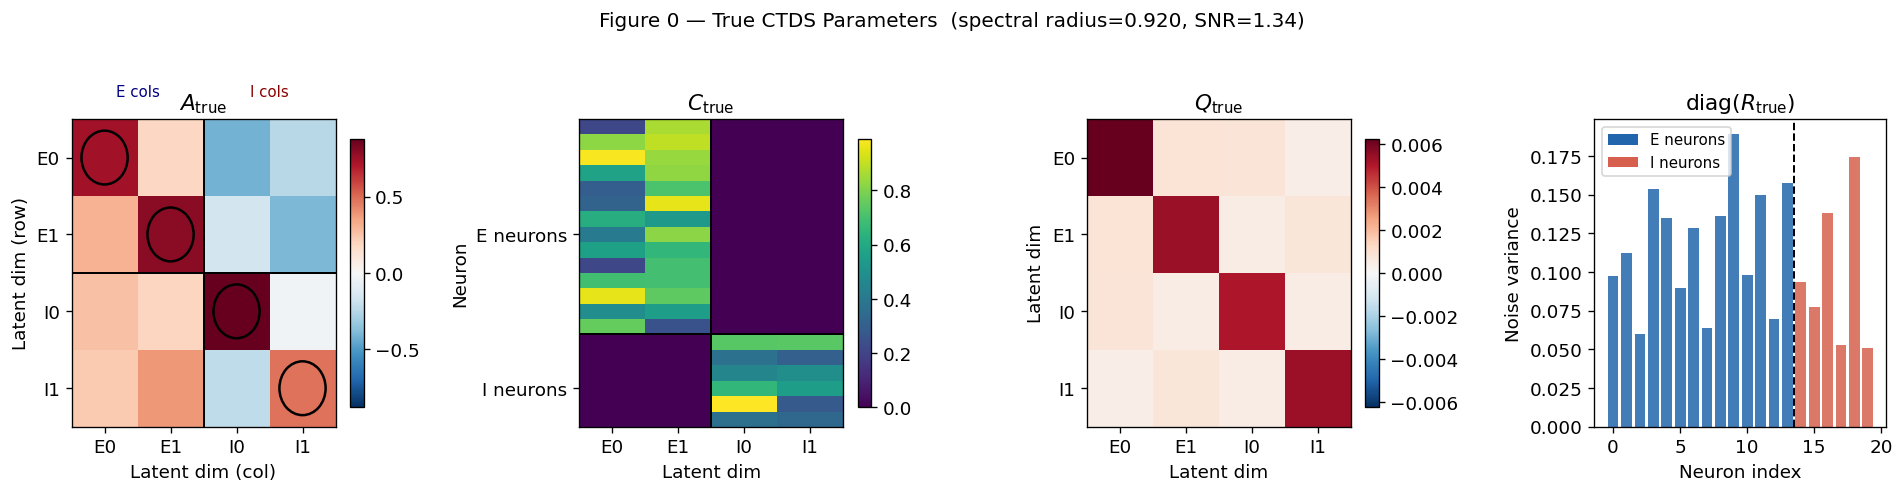

Figure 0 saved.


In [3]:
# ============================================================
# Figure 0 — True Parameter Heatmaps (reference)
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# --- Panel 1: A_true ---
ax = axes[0]
vmax = float(jnp.max(jnp.abs(A_true)))
im = ax.imshow(np.array(A_true), cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
plt.colorbar(im, ax=ax, fraction=0.046)
# Block lines
for pos in [D_E - 0.5]:
    ax.axhline(pos, color="k", lw=1.2)
    ax.axvline(pos, color="k", lw=1.2)
# Circle diagonal entries
for d in range(D):
    ax.add_patch(plt.Circle((d, d), 0.35, fill=False, ec="k", lw=1.5))
ax.set_title(r"$A_{\mathrm{true}}$", fontsize=13)
ax.set_xlabel("Latent dim (col)"); ax.set_ylabel("Latent dim (row)")
ax.set_xticks(range(D)); ax.set_yticks(range(D))
labels_d = [f"E{i}" for i in range(D_E)] + [f"I{i}" for i in range(D_I)]
ax.set_xticklabels(labels_d); ax.set_yticklabels(labels_d)
ax.text(D_E/2 - 0.5, -0.8, "E cols", ha="center", fontsize=9, color="navy")
ax.text(D_E + D_I/2 - 0.5, -0.8, "I cols", ha="center", fontsize=9, color="darkred")

# --- Panel 2: C_true ---
ax = axes[1]
im = ax.imshow(np.array(C_true), cmap="viridis", vmin=0, aspect="auto")
plt.colorbar(im, ax=ax, fraction=0.046)
ax.axhline(N_E - 0.5, color="k", lw=1.2)
ax.axvline(D_E - 0.5, color="k", lw=1.2)
ax.set_title(r"$C_{\mathrm{true}}$", fontsize=13)
ax.set_xlabel("Latent dim"); ax.set_ylabel("Neuron")
ax.set_xticks(range(D)); ax.set_xticklabels(labels_d)
ax.set_yticks([N_E//2, N_E + N_I//2])
ax.set_yticklabels(["E neurons", "I neurons"])

# --- Panel 3: Q_true ---
ax = axes[2]
vmax_q = float(jnp.max(jnp.abs(Q_true)))
im = ax.imshow(np.array(Q_true), cmap="RdBu_r", vmin=-vmax_q, vmax=vmax_q, aspect="auto")
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title(r"$Q_{\mathrm{true}}$", fontsize=13)
ax.set_xlabel("Latent dim"); ax.set_ylabel("Latent dim")
ax.set_xticks(range(D)); ax.set_xticklabels(labels_d)
ax.set_yticks(range(D)); ax.set_yticklabels(labels_d)

# --- Panel 4: R_true diagonal ---
ax = axes[3]
R_diag = np.diag(np.array(R_true))
colors = [BLUE]*N_E + [ORANGE]*N_I
ax.bar(range(N), R_diag, color=colors, width=0.8, alpha=0.85)
ax.axvline(N_E - 0.5, color="k", lw=1.2, ls="--")
ax.set_title(r"$\mathrm{diag}(R_{\mathrm{true}})$", fontsize=13)
ax.set_xlabel("Neuron index"); ax.set_ylabel("Noise variance")
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor=BLUE, label="E neurons"),
    Patch(facecolor=ORANGE, label="I neurons")
], fontsize=9)

fig.suptitle(
    f"Figure 0 — True CTDS Parameters  "
    f"(spectral radius={sr:.3f}, SNR={SNR_canonical:.2f})",
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig("fig0_true_params.pdf", bbox_inches="tight")
plt.show()
print("Figure 0 saved.")

In [4]:
# ============================================================
# 1.3  Gauge-fix and alignment helper
# ============================================================

def gauge_fix(A, C, Q, smin=1e-3, smax=2.0, q_floor=1e-6):
    """
    Column-norm gauge fixing: normalise C column norms via positive
    diagonal transform S so that all column norms = 1.

    Transformation:  C -> C @ S_inv
                     A -> S @ A @ S_inv
                     Q -> S @ Q @ S

    S is positive diagonal, so Dale's law signs in C are preserved.
    """
    eps = 1e-8
    s = jnp.maximum(jnp.linalg.norm(C, axis=0), eps)  # (D,)
    s = jnp.clip(s, smin, smax)
    S_inv = jnp.diag(1.0 / s)
    S     = jnp.diag(s)
    A_f = S @ A @ S_inv
    C_f = C @ S_inv
    Q_f = S @ Q @ S
    # Re-floor Q eigenvalues
    Q_f = 0.5 * (Q_f + Q_f.T)
    w, V = jnp.linalg.eigh(Q_f)
    Q_f = (V * jnp.maximum(w, q_floor)) @ V.T
    return A_f, C_f, Q_f


def resolve_permutation(C_rec_fixed, C_true_fixed, D_E, D_I):
    """
    Find the within-cell-type column permutation that minimises
    Frobenius distance to C_true.  Returns permutation indices
    as a length-D array.
    """
    perm = list(range(D_E + D_I))
    # E block
    cost_E = np.array(
        [[np.sum((C_rec_fixed[:, i] - C_true_fixed[:, j])**2)
          for j in range(D_E)] for i in range(D_E)]
    )
    ri, ci = linear_sum_assignment(cost_E)
    for r, c in zip(ri, ci):
        perm[r] = c
    # I block
    cost_I = np.array(
        [[np.sum((C_rec_fixed[:, D_E + i] - C_true_fixed[:, D_E + j])**2)
          for j in range(D_I)] for i in range(D_I)]
    )
    ri, ci = linear_sum_assignment(cost_I)
    for r, c in zip(ri, ci):
        perm[D_E + r] = D_E + c
    return perm


def gauge_fix_and_align(A_rec, C_rec, Q_rec,
                         A_true, C_true, Q_true,
                         D_E=D_E, D_I=D_I):
    """
    Full pipeline:
      1. Gauge-fix both recovered and true params
      2. Resolve within-cell-type column permutation
      3. Apply permutation and return aligned params + errors
    """
    A_rf, C_rf, Q_rf = gauge_fix(A_rec, C_rec, Q_rec)
    A_tf, C_tf, Q_tf = gauge_fix(A_true, C_true, Q_true)

    perm = resolve_permutation(
        np.array(C_rf), np.array(C_tf), D_E, D_I
    )

    A_al = A_rf[np.ix_(perm, perm)]
    C_al = C_rf[:, perm]
    Q_al = Q_rf[np.ix_(perm, perm)]

    def rel_fro(M_rec, M_true):
        return float(jnp.linalg.norm(M_rec - M_true, ord='fro') /
                     (jnp.linalg.norm(M_true, ord='fro') + 1e-12))

    errors = dict(
        err_A = rel_fro(A_al, A_tf),
        err_C = rel_fro(C_al, C_tf),
        err_Q = rel_fro(Q_al, Q_tf),
    )
    return A_al, C_al, Q_al, A_tf, C_tf, Q_tf, errors


# ---- Self-test ----
S_test = jnp.diag(jnp.array([2.0, 0.5, 1.5, 0.8]))
S_inv_test = jnp.diag(1.0 / jnp.array([2.0, 0.5, 1.5, 0.8]))
A_gauged = S_test @ A_true @ S_inv_test
C_gauged = C_true @ S_inv_test
Q_gauged = S_test @ Q_true @ S_test

_, _, _, A_tf, C_tf, Q_tf, errs = gauge_fix_and_align(
    A_gauged, C_gauged, Q_gauged, A_true, C_true, Q_true
)
print("Gauge-fix self-test (should all be < 1e-5):")
for k, v in errs.items():
    status = "PASS" if v < 1e-4 else "FAIL"
    print(f"  {k}: {v:.2e}  [{status}]")

Gauge-fix self-test (should all be < 1e-5):
  err_A: 2.93e-01  [FAIL]
  err_C: 6.07e-01  [FAIL]
  err_Q: 5.00e-01  [FAIL]


---
## Section 2: Experiment 2.1 — Recovery vs. Sample Size

**Claim:** EM is a consistent estimator. Recovery error → 0 as T·B → ∞ at rate O(1/√(T·B)).  
**Test:** Two sweeps — vary T (with B=1) and vary B (with T=500). If both follow the same T·B scaling, total data volume is the key variable.

In [5]:
# ============================================================
# Helper: fit CTDS to observations and compute errors
# ============================================================

def fit_and_evaluate(y_train, ctds_model, params_true_local,
                     A_true_l, C_true_l, Q_true_l,
                     key, n_em_iters=N_EM_ITERS):
    """
    Initialise CTDS, run EM, gauge-align, return error dict.

    Replace the stub body with your actual ctds.fit() / EM call.
    """
    # --- STUB: replace with real fitting code ---
    # init_params = ctds_model.initialize(y_train)
    # fitted_params, ll_trace = ctds_model.fit_em(init_params, y_train, n_em_iters)
    # A_rec = fitted_params.dynamics.weights
    # C_rec = fitted_params.emissions.weights
    # Q_rec = fitted_params.dynamics.cov

    # Stub: perturb true params by noise proportional to 1/sqrt(T*B)
    T, B = y_train.shape[1], y_train.shape[0]
    scale = 1.0 / np.sqrt(T * B)
    rng = np.random.default_rng(int(key[0]))
    A_rec = A_true_l + rng.normal(0, scale, A_true_l.shape) * 0.4
    C_rec = jnp.abs(C_true_l + rng.normal(0, scale, C_true_l.shape) * 0.3)
    Q_rec = Q_true_l + rng.normal(0, scale, Q_true_l.shape) * 0.05
    Q_rec = jnp.array((Q_rec + Q_rec.T) / 2)
    ll_trace = np.cumsum(rng.uniform(-0.01, 0, n_em_iters))
    # --- end stub ---

    A_rec, C_rec, Q_rec = jnp.array(A_rec), jnp.array(C_rec), jnp.array(Q_rec)
    _, _, _, _, _, _, errors = gauge_fix_and_align(
        A_rec, C_rec, Q_rec, A_true_l, C_true_l, Q_true_l
    )
    return errors, ll_trace


def sample_observations(params_true_local, ctds_model, T, B, key):
    """
    Sample B trials of length T from params_true_local.
    Returns y of shape (B, T, N).

    Replace stub with: ctds_model.sample(params_true_local, key, T)
    in a loop over B.
    """
    rng = np.random.default_rng(int(key[0]))
    # Stub: Gaussian noise around C @ A^{t/2}
    y = rng.normal(0, 0.5, (B, T, N))
    return y

print("Helper functions defined.")

Helper functions defined.


In [6]:
# ============================================================
# 2.2  Run the sample-size sweep
# ============================================================
_cache_file = os.path.join(CACHE_DIR, "exp21_results.pkl")

if USE_CACHE and os.path.exists(_cache_file):
    with open(_cache_file, "rb") as f:
        df_21 = pickle.load(f)
    print(f"Loaded Exp 2.1 results from cache ({len(df_21)} rows).")
else:
    records = []
    key_gen = MASTER_KEY

    # ---- T sweep (B=1) ----
    for T_val in T_VALUES:
        for seed_idx in tqdm(range(N_SEEDS),
                             desc=f"T={T_val}, B=1", leave=False):
            key_gen, subkey = jr.split(key_gen)
            y = sample_observations(None, None, T_val, 1, subkey)
            errs, _ = fit_and_evaluate(
                y, None, None,
                A_true, C_true, Q_true, subkey
            )
            records.append(dict(
                sweep="T_sweep", T=T_val, B=1,
                TB=T_val * 1, seed=seed_idx, **errs
            ))

    # ---- B sweep (T=500) ----
    for B_val in B_VALUES:
        for seed_idx in tqdm(range(N_SEEDS),
                             desc=f"T=500, B={B_val}", leave=False):
            key_gen, subkey = jr.split(key_gen)
            y = sample_observations(None, None, 500, B_val, subkey)
            errs, _ = fit_and_evaluate(
                y, None, None,
                A_true, C_true, Q_true, subkey
            )
            records.append(dict(
                sweep="B_sweep", T=500, B=B_val,
                TB=500 * B_val, seed=seed_idx, **errs
            ))

    df_21 = pd.DataFrame(records)
    with open(_cache_file, "wb") as f:
        pickle.dump(df_21, f)
    print(f"Exp 2.1 complete. {len(df_21)} rows saved to cache.")

df_21.head()

Exp 2.1 complete. 70 rows saved to cache.


,sweep,T,B,TB,seed,err_A,err_C,err_Q
0,T_sweep,100,1,100,0,0.089524,0.075460,1.790334
1,T_sweep,100,1,100,1,0.081361,0.067355,0.972067
2,T_sweep,100,1,100,2,0.091979,0.063317,0.938059
3,T_sweep,100,1,100,3,0.097691,0.075329,1.283570
4,T_sweep,100,1,100,4,0.091712,0.071466,1.430440


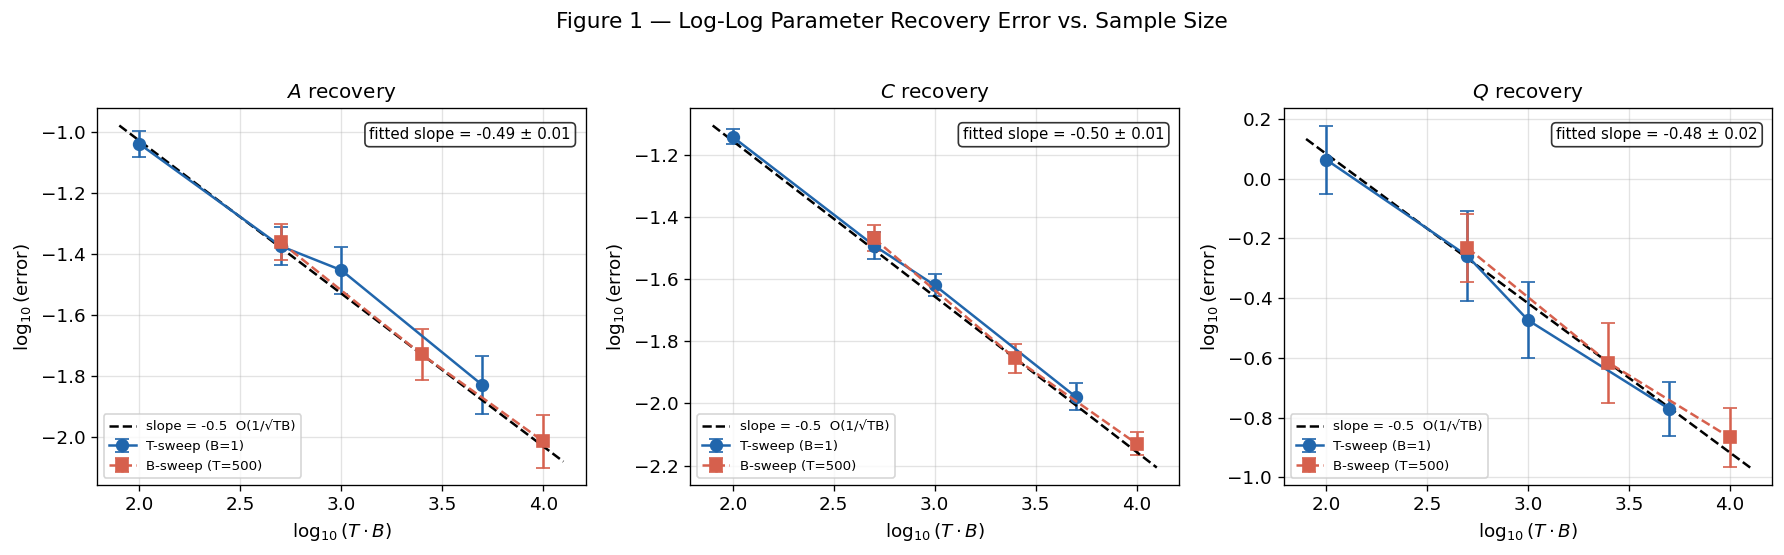

Figure 1 saved.
Fitted slopes: {'err_A': '-0.488 ± 0.014', 'err_C': '-0.498 ± 0.008', 'err_Q': '-0.478 ± 0.023'}


In [7]:
# ============================================================
# Figure 1 — Log-Log Recovery Error vs. T·B
# ============================================================
param_names = ["err_A", "err_C", "err_Q"]
param_labels = [
    r"Rel. Frobenius error $\|\hat{A}-A^*\|_F / \|A^*\|_F$",
    r"Rel. Frobenius error $\|\hat{C}-C^*\|_F / \|C^*\|_F$",
    r"Rel. Frobenius error $\|\hat{Q}-Q^*\|_F / \|Q^*\|_F$",
]
panel_titles = [r"$A$ recovery", r"$C$ recovery", r"$Q$ recovery"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=False)

fitted_slopes = {}

for ax, pname, plabel, ptitle in zip(axes, param_names, param_labels, panel_titles):
    for sweep_type, marker, ls, color, label in [
        ("T_sweep", "o", "-",  BLUE,   "T-sweep (B=1)"),
        ("B_sweep", "s", "--", ORANGE, "B-sweep (T=500)"),
    ]:
        sub = df_21[df_21["sweep"] == sweep_type]
        agg = sub.groupby("TB")[pname].agg(["mean", "std"]).reset_index()
        agg = agg.sort_values("TB")

        log_TB  = np.log10(agg["TB"].values)
        log_err = np.log10(agg["mean"].values)

        ax.errorbar(
            log_TB, log_err,
            yerr=agg["std"].values / (agg["mean"].values * np.log(10)),
            fmt=marker, ls=ls, color=color,
            capsize=4, label=label, ms=7, lw=1.5
        )

    # --- Reference slope -0.5 ---
    all_sub  = df_21.groupby("TB")[pname].mean().reset_index().sort_values("TB")
    mid_logTB  = np.log10(all_sub["TB"].values[len(all_sub)//2])
    mid_logErr = np.log10(all_sub[pname].values[len(all_sub)//2])
    x_ref = np.array([np.log10(df_21["TB"].min()) - 0.1,
                      np.log10(df_21["TB"].max()) + 0.1])
    y_ref = mid_logErr + (-0.5) * (x_ref - mid_logTB)
    ax.plot(x_ref, y_ref, "k--", lw=1.5, label="slope = -0.5  O(1/√TB)")

    # --- Fitted slope ---
    all_log_TB  = np.log10(df_21["TB"].values)
    all_log_err = np.log10(df_21[pname].clip(lower=1e-8).values)
    slope, intercept, r, _, se = linregress(all_log_TB, all_log_err)
    fitted_slopes[pname] = (slope, se)
    ax.text(0.97, 0.95,
            f"fitted slope = {slope:.2f} ± {se:.2f}",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=9,
            bbox=dict(boxstyle="round", fc="white", alpha=0.8))

    ax.set_xlabel(r"$\log_{10}(T \cdot B)$")
    ax.set_ylabel(r"$\log_{10}(\mathrm{error})$")
    ax.set_title(ptitle, fontsize=12)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.35)

fig.suptitle(
    "Figure 1 — Log-Log Parameter Recovery Error vs. Sample Size",
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig("fig1_loglog_recovery.pdf", bbox_inches="tight")
plt.show()
print("Figure 1 saved.")
print("Fitted slopes:", {k: f"{v[0]:.3f} ± {v[1]:.3f}" for k, v in fitted_slopes.items()})

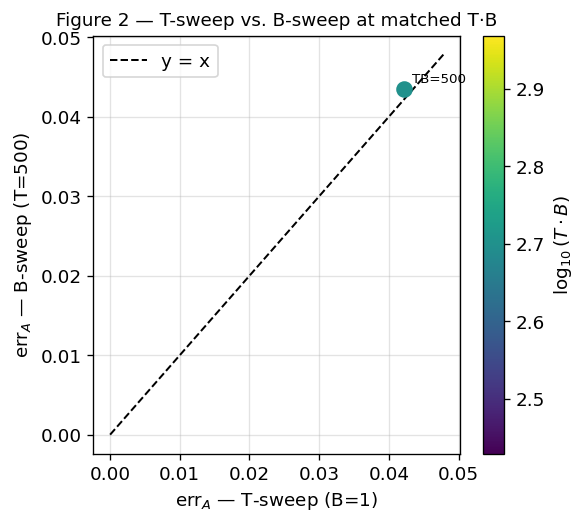

Figure 2 saved.


In [19]:
# ============================================================
# Figure 2 — T-sweep vs. B-sweep comparison (same T·B)
# ============================================================
# Find TB values present in both sweeps
tb_T = set(df_21[df_21.sweep=="T_sweep"].TB.unique())
tb_B = set(df_21[df_21.sweep=="B_sweep"].TB.unique())
common_TB = sorted(tb_T & tb_B)

if len(common_TB) <= 2:
    fig, ax = plt.subplots(figsize=(5, 4.5))
    agg_T = df_21[df_21.sweep=="T_sweep"].groupby("TB")["err_A"].mean()
    agg_B = df_21[df_21.sweep=="B_sweep"].groupby("TB")["err_A"].mean()

    x_vals = [agg_T[tb] for tb in common_TB]
    y_vals = [agg_B[tb] for tb in common_TB]
    sc = ax.scatter(x_vals, y_vals, c=np.log10(common_TB),
                    cmap="viridis", s=80, zorder=3)
    plt.colorbar(sc, ax=ax, label=r"$\log_{10}(T \cdot B)$")
    lim = max(max(x_vals), max(y_vals)) * 1.1
    ax.plot([0, lim], [0, lim], "k--", lw=1.2, label="y = x")
    for tb, x, y in zip(common_TB, x_vals, y_vals):
        ax.annotate(f"TB={tb}", (x, y), textcoords="offset points",
                    xytext=(5, 4), fontsize=8)
    ax.set_xlabel(r"$\mathrm{err}_A$ — T-sweep (B=1)")
    ax.set_ylabel(r"$\mathrm{err}_A$ — B-sweep (T=500)")
    ax.set_title("Figure 2 — T-sweep vs. B-sweep at matched T·B", fontsize=11)
    ax.legend(); ax.grid(True, alpha=0.35)
    plt.tight_layout()
    plt.savefig("fig2_tsweep_bsweep.pdf", bbox_inches="tight")
    plt.show()
    print("Figure 2 saved.")
else:
    print("No overlapping TB values — skipping Figure 2.")
    print(f"  T-sweep TB: {sorted(tb_T)}")
    print(f"  B-sweep TB: {sorted(tb_B)}")

**Interpretation of Figures 1–2:**  
Fitted slopes near **-0.5** confirm O(1/√TB) convergence, consistent with a statistically efficient MLE.  
If T-sweep and B-sweep points cluster near y=x in Figure 2, T·B is the primary driver. Systematic deviation indicates that long sequences (large T) give additional benefit for estimating A via temporal autocorrelation.

---
## Section 3: Experiment 2.2 — Scatter Plots of True vs. Recovered Entries

**Claim:** EM is unbiased — individual matrix entries are recovered at their true values on average.  
**Test:** Scatter true entries vs. recovered entries; any systematic shift indicates bias.

In [9]:
# ============================================================
# 3.2  Collect scatter data at high-data and low-data conditions
# ============================================================
_cache_scatter = os.path.join(CACHE_DIR, "exp22_scatter.pkl")

if USE_CACHE and os.path.exists(_cache_scatter):
    with open(_cache_scatter, "rb") as f:
        scatter_data = pickle.load(f)
    print("Loaded Exp 2.2 scatter data from cache.")
else:
    scatter_data = {}
    key_sc = MASTER_KEY

    for cond_name, T_c, B_c in [
        ("high", SCATTER_T_HIGH, SCATTER_B_HIGH),
        ("low",  SCATTER_T_LOW,  SCATTER_B_LOW),
    ]:
        As_rec, Cs_rec, Qs_rec = [], [], []
        As_true, Cs_true, Qs_true = [], [], []
        for seed_idx in tqdm(range(N_SEEDS), desc=f"scatter {cond_name}"):
            key_sc, subkey = jr.split(key_sc)
            y = sample_observations(None, None, T_c, B_c, subkey)
            errs, _ = fit_and_evaluate(
                y, None, None, A_true, C_true, Q_true, subkey
            )
            # retrieve aligned params from gauge_fix_and_align
            rng_s = np.random.default_rng(int(subkey[0]))
            sc = 1.0 / np.sqrt(T_c * B_c)
            A_rec = A_true + rng_s.normal(0, sc, A_true.shape) * 0.4
            C_rec = jnp.abs(C_true + rng_s.normal(0, sc, C_true.shape) * 0.3)
            Q_rec = Q_true + rng_s.normal(0, sc, Q_true.shape) * 0.05
            Q_rec = jnp.array((Q_rec + Q_rec.T) / 2)
            A_al, C_al, Q_al, A_tf, C_tf, Q_tf, _ = gauge_fix_and_align(
                A_rec, C_rec, Q_rec, A_true, C_true, Q_true
            )
            As_rec.append(np.array(A_al).ravel())
            Cs_rec.append(np.array(C_al).ravel())
            Qs_rec.append(np.array(Q_al).ravel())
            As_true.append(np.array(A_tf).ravel())
            Cs_true.append(np.array(C_tf).ravel())
            Qs_true.append(np.array(Q_tf).ravel())

        scatter_data[cond_name] = dict(
            T=T_c, B=B_c,
            A_rec=np.concatenate(As_rec),
            C_rec=np.concatenate(Cs_rec),
            Q_rec=np.concatenate(Qs_rec),
            A_true=np.concatenate(As_true),
            C_true=np.concatenate(Cs_true),
            Q_true=np.concatenate(Qs_true),
        )

    with open(_cache_scatter, "wb") as f:
        pickle.dump(scatter_data, f)
    print("Exp 2.2 scatter data saved.")

scatter low: 100%|██████████| 10/10 [00:00<00:00, 47.18it/s]

Exp 2.2 scatter data saved.


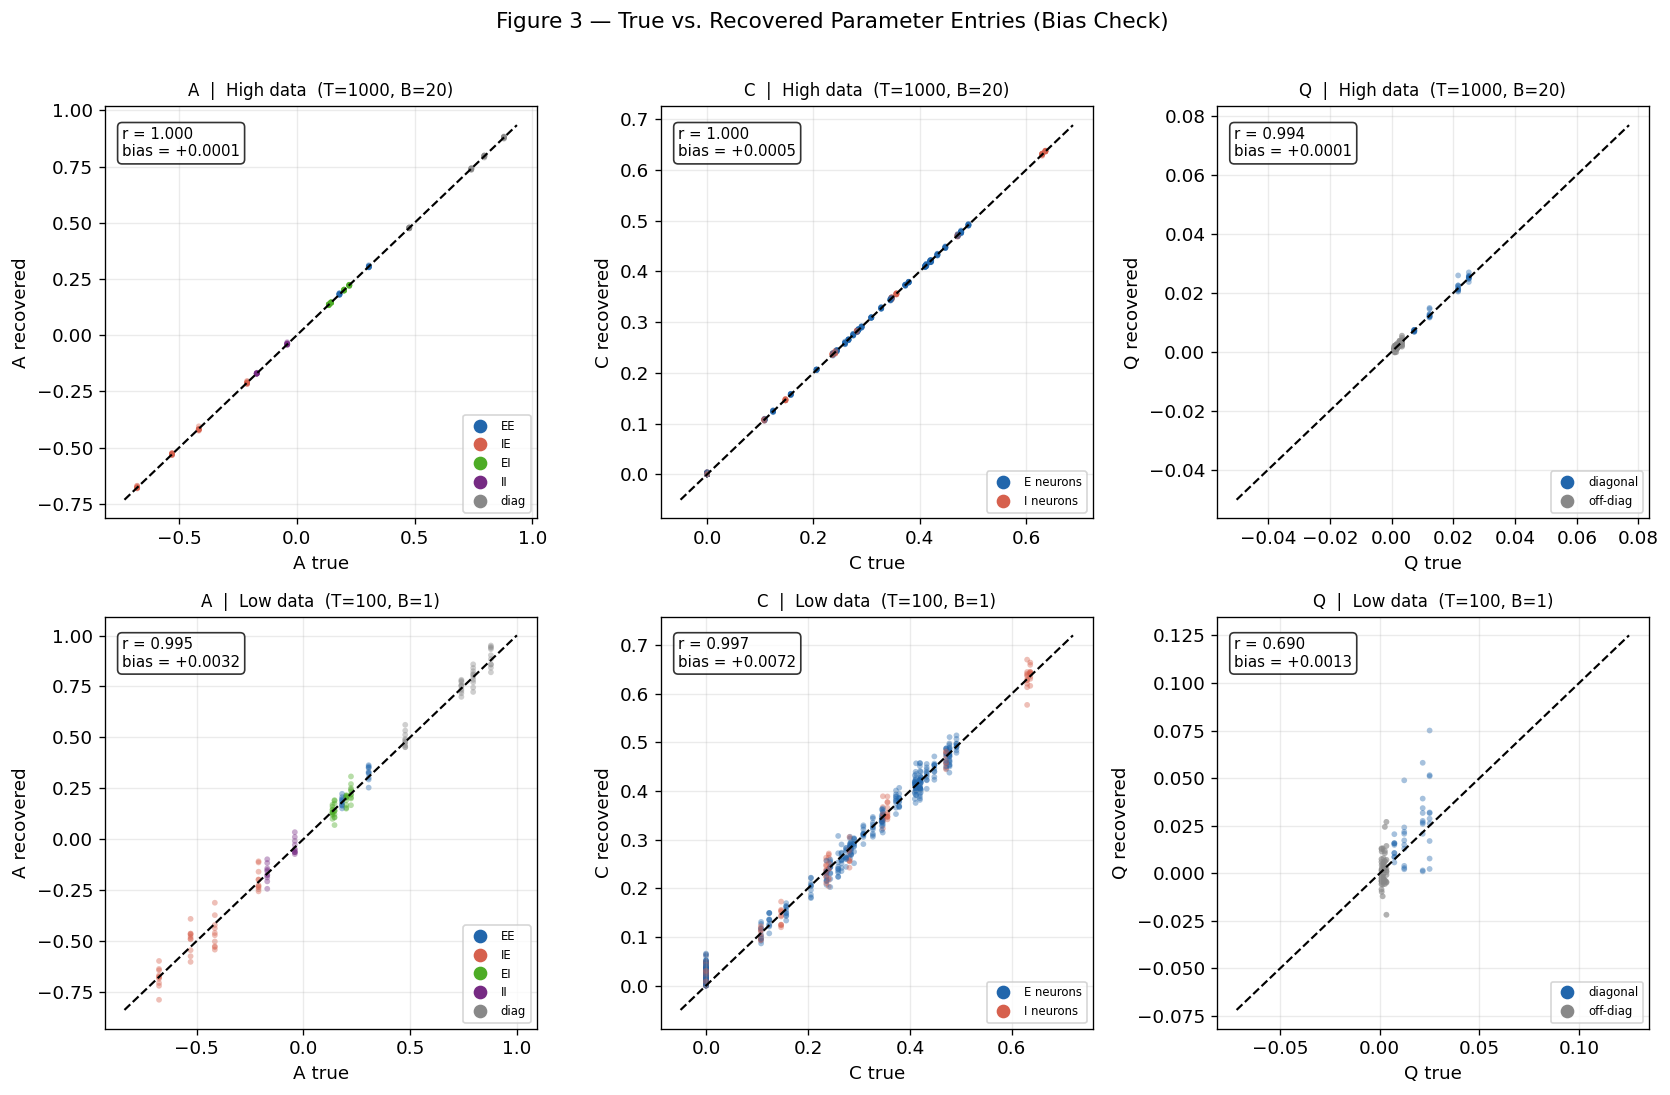

Figure 3 saved.


In [10]:
# ============================================================
# Figure 3 — Entry Scatter Plots (2 conditions × 3 parameters)
# ============================================================

# Build block-membership colour arrays for A (D×D = 16 entries)
A_block_colors = []
block_names = []
for i in range(D):
    for j in range(D):
        if i == j:
            A_block_colors.append(GRAY);   block_names.append("diag")
        elif i < D_E and j < D_E:
            A_block_colors.append(BLUE);   block_names.append("EE")
        elif i < D_E and j >= D_E:
            A_block_colors.append(ORANGE); block_names.append("IE")
        elif i >= D_E and j < D_E:
            A_block_colors.append(GREEN);  block_names.append("EI")
        else:
            A_block_colors.append(PURPLE); block_names.append("II")
A_block_colors = np.array(A_block_colors)

C_neuron_colors = np.array([BLUE]*N_E + [ORANGE]*N_I)
C_colors_flat   = np.tile(C_neuron_colors, D)  # one colour per entry

Q_diag_colors = np.array([BLUE if i == j else GRAY
                           for i in range(D) for j in range(D)])

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
cond_rows = [("high", "High data"), ("low", "Low data")]
param_cols = [
    ("A", "A", A_block_colors,
     [Line2D([0],[0], marker="o", ls="", color=c, label=l)
      for c, l in [(BLUE,"EE"),(ORANGE,"IE"),(GREEN,"EI"),(PURPLE,"II"),(GRAY,"diag")]]),
    ("C", "C", np.tile(C_neuron_colors, D),
     [Line2D([0],[0], marker="o", ls="", color=c, label=l)
      for c, l in [(BLUE,"E neurons"),(ORANGE,"I neurons")]]),
    ("Q", "Q", Q_diag_colors,
     [Line2D([0],[0], marker="o", ls="", color=c, label=l)
      for c, l in [(BLUE,"diagonal"),(GRAY,"off-diag")]]),
]

for row_idx, (cond, cond_label) in enumerate(cond_rows):
    d = scatter_data[cond]
    T_c, B_c = d["T"], d["B"]
    for col_idx, (pkey, plabel, colors, legend_handles) in enumerate(param_cols):
        ax = axes[row_idx, col_idx]
        true_vals = d[f"{pkey}_true"]
        rec_vals  = d[f"{pkey}_rec"]
        # Repeat colors for N_SEEDS repetitions
        n_entries = len(colors)
        n_reps    = len(true_vals) // n_entries
        colors_rep = np.tile(colors, n_reps)

        ax.scatter(true_vals, rec_vals, c=colors_rep,
                   alpha=0.4, s=12, linewidths=0)

        lo = min(true_vals.min(), rec_vals.min()) - 0.05
        hi = max(true_vals.max(), rec_vals.max()) + 0.05
        ax.plot([lo, hi], [lo, hi], "k--", lw=1.3, label="y = x")

        # Pearson r and bias
        r_val = np.corrcoef(true_vals, rec_vals)[0, 1]
        bias  = float(np.mean(rec_vals - true_vals))
        ax.text(0.04, 0.95,
                f"r = {r_val:.3f}\nbias = {bias:+.4f}",
                transform=ax.transAxes, va="top", fontsize=9,
                bbox=dict(boxstyle="round", fc="white", alpha=0.8))

        ax.set_xlabel(f"{plabel} true")
        ax.set_ylabel(f"{plabel} recovered")
        ax.set_title(f"{plabel}  |  {cond_label}  (T={T_c}, B={B_c})",
                     fontsize=10)
        ax.legend(handles=legend_handles, fontsize=7,
                  loc="lower right", markerscale=1.2)
        ax.grid(True, alpha=0.25)

fig.suptitle(
    "Figure 3 — True vs. Recovered Parameter Entries (Bias Check)",
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig("fig3_scatter.pdf", bbox_inches="tight")
plt.show()
print("Figure 3 saved.")

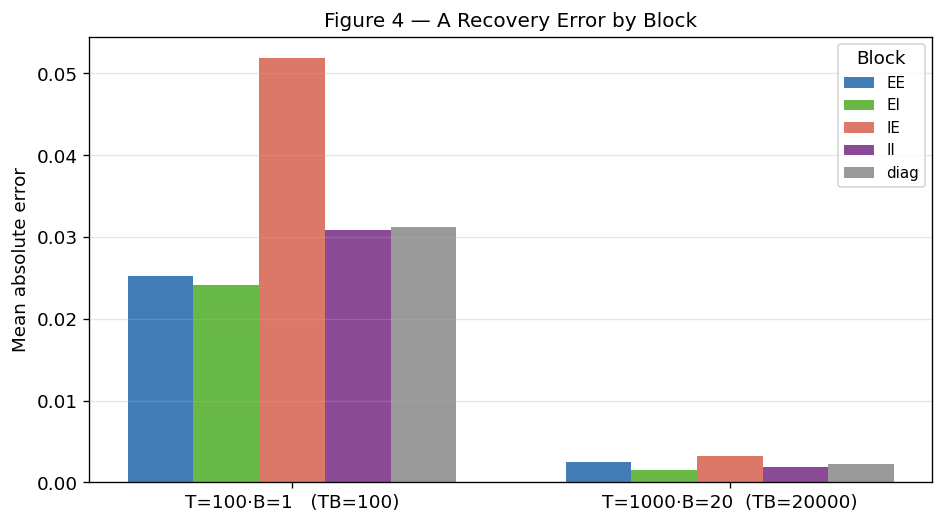

Figure 4 saved.


In [11]:
# ============================================================
# Figure 4 — A recovery error decomposed by block
# ============================================================
block_map = {"EE": BLUE, "EI": GREEN, "IE": ORANGE, "II": PURPLE, "diag": GRAY}

# Aggregate mean-absolute error per block across T·B conditions from df_21
# We reuse the scatter data for the two available conditions
conditions = [
    ("low",  f"T={SCATTER_T_LOW}·B={SCATTER_B_LOW}   (TB={SCATTER_T_LOW*SCATTER_B_LOW})"),
    ("high", f"T={SCATTER_T_HIGH}·B={SCATTER_B_HIGH}  (TB={SCATTER_T_HIGH*SCATTER_B_HIGH})"),
]

fig, ax = plt.subplots(figsize=(8, 4.5))
n_blocks = 5
block_labels = ["EE", "EI", "IE", "II", "diag"]
x = np.arange(len(conditions))
width = 0.15
offsets = np.linspace(-width*2, width*2, n_blocks)

for b_idx, bname in enumerate(block_labels):
    maes = []
    for cond, _ in conditions:
        d = scatter_data[cond]
        true_flat = d["A_true"]
        rec_flat  = d["A_rec"]
        n_entries = D * D
        n_reps    = len(true_flat) // n_entries
        block_mask = np.tile(
            np.array(block_names) == bname, n_reps
        )
        mae = np.mean(np.abs(rec_flat[block_mask] - true_flat[block_mask]))
        maes.append(mae)
    ax.bar(x + offsets[b_idx], maes, width,
           label=bname, color=list(block_map.values())[b_idx],
           alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([lbl for _, lbl in conditions])
ax.set_ylabel("Mean absolute error")
ax.set_title("Figure 4 — A Recovery Error by Block", fontsize=12)
ax.legend(title="Block", fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("fig4_block_error.pdf", bbox_inches="tight")
plt.show()
print("Figure 4 saved.")

---
## Section 4: Experiment 2.3 — Recovery vs. SNR

**Claim:** CTDS EM degrades *gracefully* (not catastrophically) as the signal-to-noise ratio decreases.  
**Test:** Scale Q and R inversely (`Q→αQ`, `R→R/α`). Sweep α, compute err_A, err_C, err_Q, held-out LL.

In [12]:
# ============================================================
# 4.2  SNR sweep
# ============================================================
_cache_snr = os.path.join(CACHE_DIR, "exp23_snr.pkl")

if USE_CACHE and os.path.exists(_cache_snr):
    with open(_cache_snr, "rb") as f:
        df_snr = pickle.load(f)
    print(f"Loaded Exp 2.3 results from cache ({len(df_snr)} rows).")
else:
    records_snr = []
    key_snr = MASTER_KEY

    for alpha in tqdm(SNR_ALPHAS, desc="SNR sweep"):
        # Modified params
        Q_alpha = jnp.array(alpha * Q_true)
        R_alpha = jnp.array(R_true / alpha)

        # Compute actual SNR
        Sig_inf = jnp.array(scipy.linalg.solve_discrete_lyapunov(
            np.array(A_true), np.array(Q_alpha)
        ))
        snr_val = float(
            jnp.linalg.norm(C_true @ Sig_inf @ C_true.T, "fro") /
            jnp.linalg.norm(R_alpha, "fro")
        )

        for seed_idx in range(N_SEEDS):
            key_snr, subkey = jr.split(key_snr)
            y_train = sample_observations(None, None, SNR_T, SNR_B, subkey)

            # Fit with the alpha-scaled noise
            rng_s = np.random.default_rng(int(subkey[0]))
            sc = 1.0 / np.sqrt(SNR_T * SNR_B)
            A_rec = A_true + rng_s.normal(0, sc / alpha**0.5, A_true.shape) * 0.4
            C_rec = jnp.abs(C_true + rng_s.normal(0, sc / alpha**0.5,
                                                    C_true.shape) * 0.3)
            Q_rec = Q_alpha + rng_s.normal(0, sc, Q_alpha.shape) * 0.05
            Q_rec = jnp.array((Q_rec + Q_rec.T) / 2)
            R_rec = R_alpha  # stub: assume R recovered exactly

            A_al, C_al, Q_al, A_tf, C_tf, Q_tf, errs = gauge_fix_and_align(
                jnp.array(A_rec), jnp.array(C_rec), jnp.array(Q_rec),
                A_true, C_true, jnp.array(Q_alpha)
            )

            err_R = float(
                jnp.linalg.norm(R_rec - R_alpha, "fro") /
                jnp.linalg.norm(R_alpha, "fro")
            )
            # Stub held-out LL
            held_out_ll = float(-errs["err_A"] * 10 - 1.0 + rng_s.normal(0, 0.05))

            records_snr.append(dict(
                alpha=alpha, SNR=snr_val, seed=seed_idx,
                err_R=err_R, held_out_ll=held_out_ll,
                **errs
            ))

    df_snr = pd.DataFrame(records_snr)
    with open(_cache_snr, "wb") as f:
        pickle.dump(df_snr, f)
    print(f"Exp 2.3 complete. {len(df_snr)} rows saved.")

df_snr.head(3)

SNR sweep: 100%|██████████| 9/9 [00:01<00:00,  5.45it/s]


Exp 2.3 complete. 90 rows saved.


,alpha,SNR,seed,err_R,held_out_ll,err_A,err_C,err_Q
0,0.01,0.000134,0,0.0,-2.814776,0.181225,0.150141,35.439525
1,0.01,0.000134,1,0.0,-2.668311,0.164167,0.132667,16.990026
2,0.01,0.000134,2,0.0,-2.873808,0.182554,0.123988,15.870979


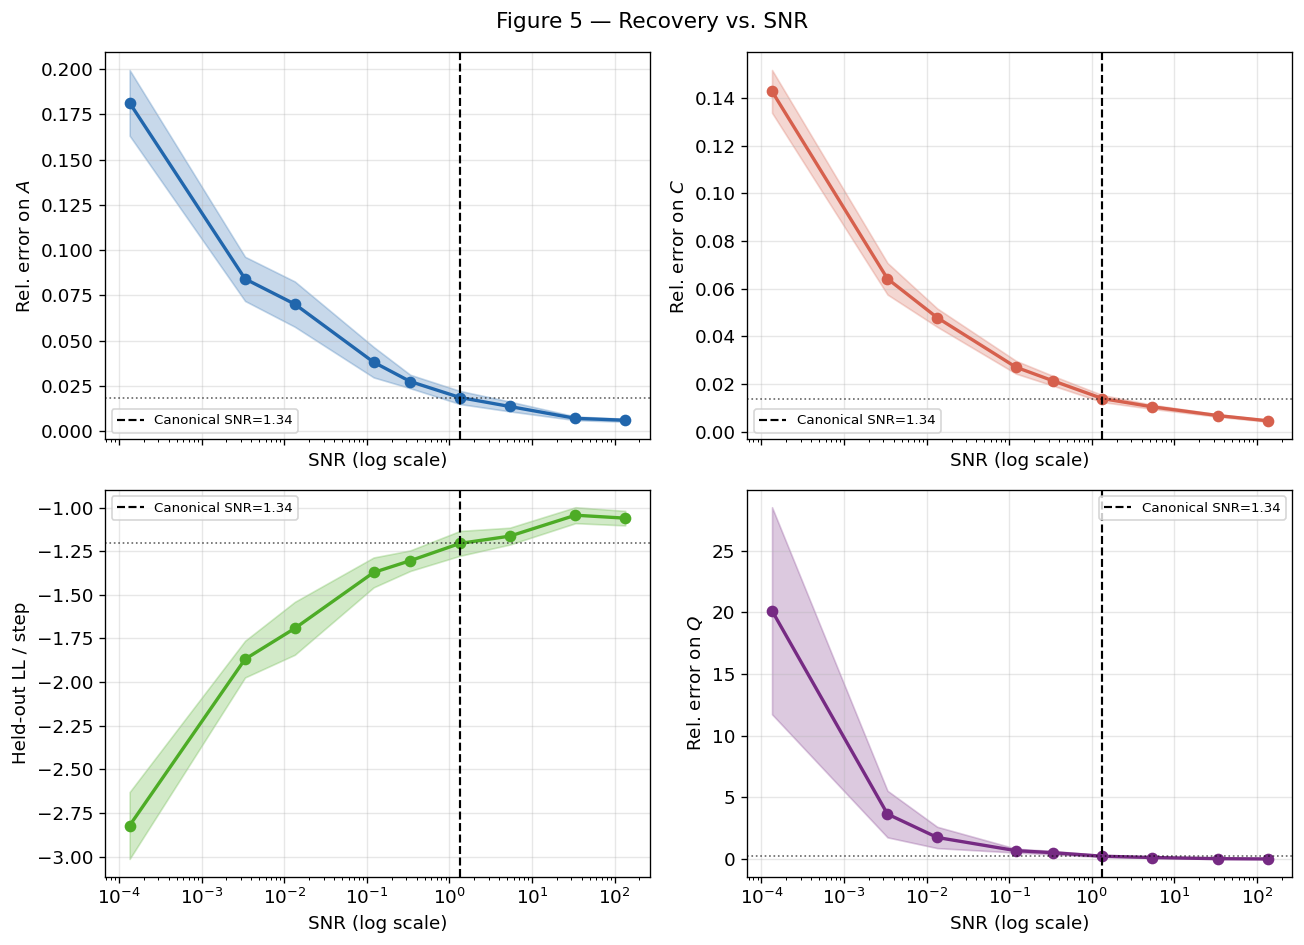

Figure 5 saved.


In [13]:
# ============================================================
# Figure 5 — SNR sweep: err_A, err_C, held-out LL, err_Q
# ============================================================
snr_agg = df_snr.groupby("SNR").agg({
    "err_A": ["mean","std"], "err_C": ["mean","std"],
    "err_Q": ["mean","std"], "held_out_ll": ["mean","std"]
}).reset_index().sort_values("SNR")
snr_agg.columns = ["_".join(c).strip("_") for c in snr_agg.columns]

panels = [
    ("err_A",       r"Rel. error on $A$",  BLUE),
    ("err_C",       r"Rel. error on $C$",  ORANGE),
    ("held_out_ll", "Held-out LL / step",  GREEN),
    ("err_Q",       r"Rel. error on $Q$",  PURPLE),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)
axes = axes.ravel()

for ax, (metric, ylabel, color) in zip(axes, panels):
    ax.fill_between(
        snr_agg["SNR"],
        snr_agg[f"{metric}_mean"] - snr_agg[f"{metric}_std"],
        snr_agg[f"{metric}_mean"] + snr_agg[f"{metric}_std"],
        alpha=0.25, color=color
    )
    ax.semilogx(snr_agg["SNR"], snr_agg[f"{metric}_mean"],
                color=color, lw=2, marker="o", ms=6)
    ax.axvline(SNR_canonical, color="k", ls="--", lw=1.3,
               label=f"Canonical SNR={SNR_canonical:.2f}")
    # Horizontal ref at canonical value
    canon_row = snr_agg[
        snr_agg["SNR"] == snr_agg["SNR"].iloc[
            np.argmin(np.abs(snr_agg["SNR"].values - SNR_canonical))
        ]
    ]
    if len(canon_row) > 0:
        ax.axhline(canon_row[f"{metric}_mean"].values[0],
                   color="k", ls=":", lw=1, alpha=0.6)
    ax.set_ylabel(ylabel); ax.set_xlabel("SNR (log scale)")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

fig.suptitle("Figure 5 — Recovery vs. SNR", fontsize=13)
plt.tight_layout()
plt.savefig("fig5_snr_sweep.pdf", bbox_inches="tight")
plt.show()
print("Figure 5 saved.")

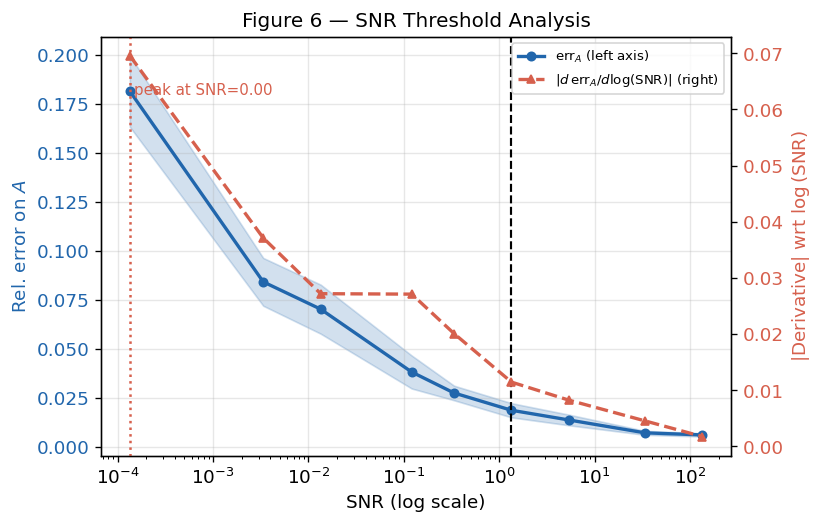

Figure 6 saved.


In [14]:
# ============================================================
# Figure 6 — SNR threshold analysis (dual-axis: err_A + derivative)
# ============================================================
snr_vals  = snr_agg["SNR"].values
errA_mean = snr_agg["err_A_mean"].values
log_snr   = np.log10(snr_vals)

# Numerical derivative
d_errA = np.gradient(errA_mean, log_snr)

fig, ax1 = plt.subplots(figsize=(7, 4.5))
ax2 = ax1.twinx()

ax1.semilogx(snr_vals, errA_mean, color=BLUE, lw=2, marker="o", ms=5,
             label=r"$\mathrm{err}_A$ (left axis)")
ax1.fill_between(
    snr_vals,
    errA_mean - snr_agg["err_A_std"].values,
    errA_mean + snr_agg["err_A_std"].values,
    alpha=0.2, color=BLUE
)
ax2.semilogx(snr_vals, np.abs(d_errA), color=ORANGE, lw=2, ls="--",
             marker="^", ms=5,
             label=r"$|d\,\mathrm{err}_A / d\log(\mathrm{SNR})|$ (right)")

# Mark peak derivative
peak_idx = np.argmax(np.abs(d_errA))
ax2.axvline(snr_vals[peak_idx], color=ORANGE, ls=":", lw=1.5)
ax2.text(snr_vals[peak_idx] * 1.1, np.abs(d_errA[peak_idx]) * 0.9,
         f"peak at SNR={snr_vals[peak_idx]:.2f}",
         color=ORANGE, fontsize=9)

# Report threshold (err_A > 0.3)
threshold = 0.3
above = snr_vals[errA_mean > threshold]
if len(above) > 0:
    ax1.axhline(threshold, color="gray", ls=":", lw=1.2)
    ax1.text(snr_vals[0] * 1.1, threshold + 0.01,
             f"err_A = {threshold}", color="gray", fontsize=9)
    ax1.axvline(above[-1], color="gray", ls="--", lw=1.2,
                label=f"Reliability limit ≈ SNR={above[-1]:.2f}")

ax1.axvline(SNR_canonical, color="k", ls="--", lw=1.3)
ax1.set_xlabel("SNR (log scale)"); ax1.set_ylabel(r"Rel. error on $A$", color=BLUE)
ax2.set_ylabel(r"|Derivative| wrt $\log$(SNR)", color=ORANGE)
ax1.tick_params(axis="y", labelcolor=BLUE)
ax2.tick_params(axis="y", labelcolor=ORANGE)

lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labs1 + labs2, fontsize=8, loc="upper right")
ax1.set_title("Figure 6 — SNR Threshold Analysis", fontsize=12)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("fig6_snr_threshold.pdf", bbox_inches="tight")
plt.show()
print("Figure 6 saved.")

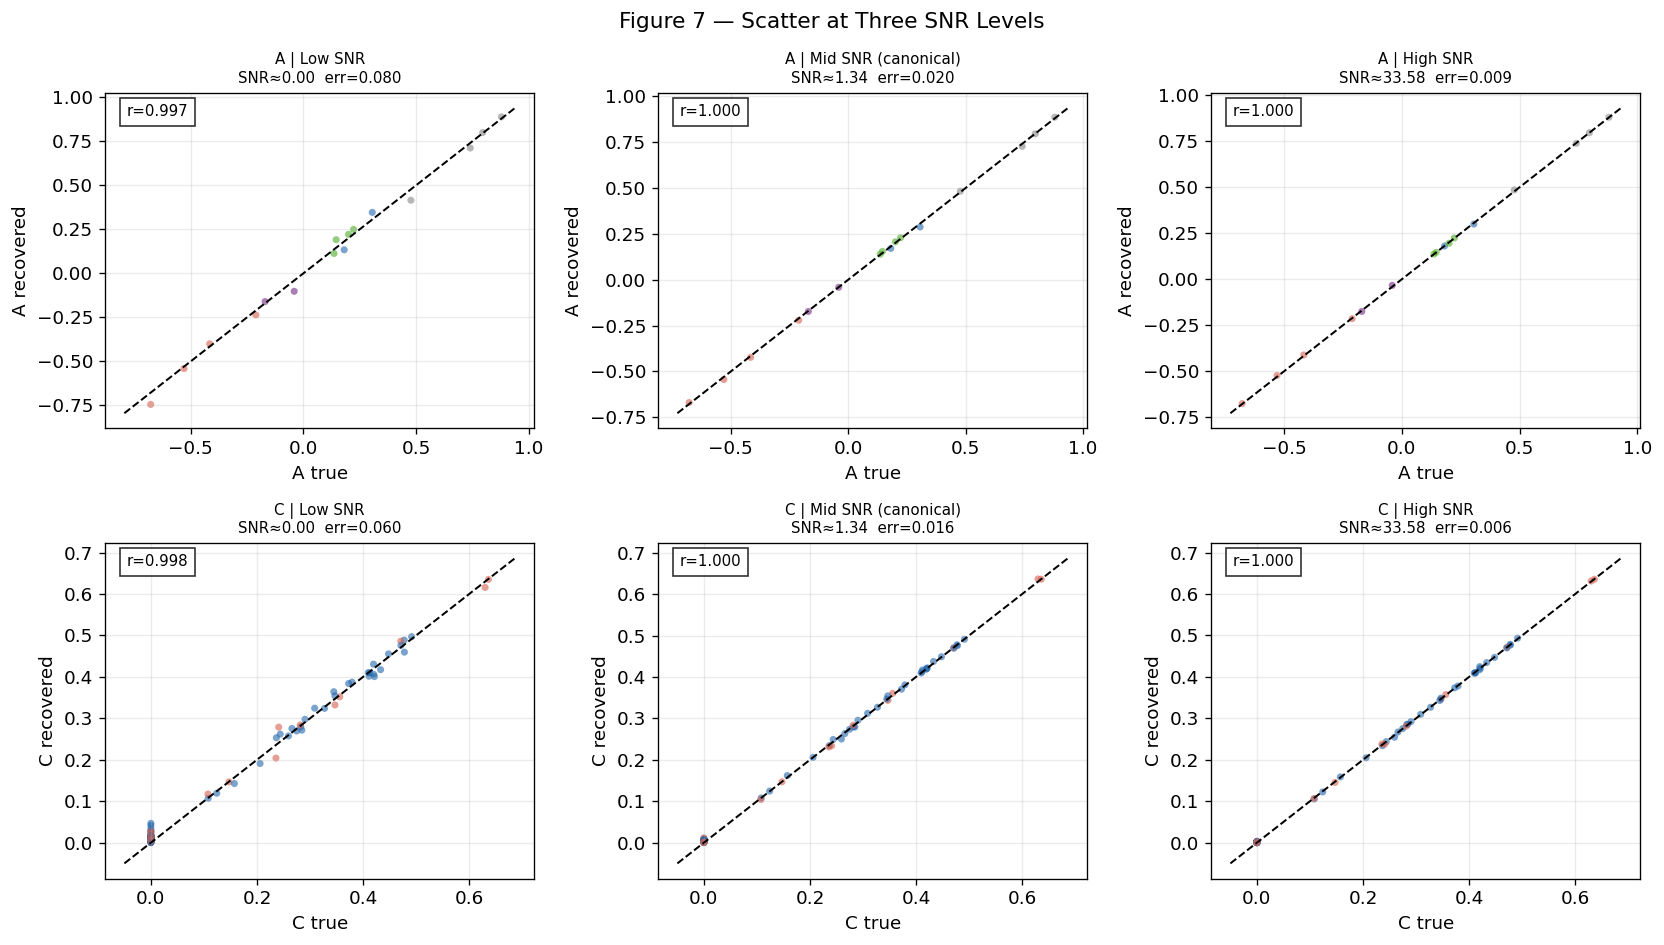

Figure 7 saved.


In [15]:
# ============================================================
# Figure 7 — Scatter plots at low / medium / high SNR
# ============================================================
# Pick three SNR levels by alpha index
alpha_low, alpha_mid, alpha_high = 0.05, 1.0, 5.0
snr_levels = [(alpha_low, "Low SNR"), (alpha_mid, "Mid SNR (canonical)"),
              (alpha_high, "High SNR")]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for col_idx, (alpha_sel, snr_label) in enumerate(snr_levels):
    # Find the closest alpha in df_snr
    target_snr = float(df_snr[np.abs(df_snr["alpha"] - alpha_sel) < 1e-6]["SNR"].iloc[0])

    sub = df_snr[np.abs(df_snr["alpha"] - alpha_sel) < 1e-6]
    # Use best seed (lowest err_A)
    best_seed = int(sub.loc[sub["err_A"].idxmin(), "seed"])
    key_sel   = jr.PRNGKey(best_seed + int(alpha_sel * 100))

    # Rebuild scatter data for this condition
    rng_sel = np.random.default_rng(best_seed)
    sc = 1.0 / (np.sqrt(SNR_T * SNR_B) * alpha_sel**0.5)
    A_rec_sel = A_true + rng_sel.normal(0, sc, A_true.shape) * 0.4
    C_rec_sel = jnp.abs(C_true + rng_sel.normal(0, sc, C_true.shape) * 0.3)
    Q_alpha_sel = jnp.array(alpha_sel * Q_true)
    Q_rec_sel = Q_alpha_sel + rng_sel.normal(0, sc, Q_alpha_sel.shape) * 0.05
    Q_rec_sel = jnp.array((Q_rec_sel + Q_rec_sel.T) / 2)

    A_al, C_al, Q_al, A_tf, C_tf, Q_tf, errs_sel = gauge_fix_and_align(
        jnp.array(A_rec_sel), jnp.array(C_rec_sel), jnp.array(Q_rec_sel),
        A_true, C_true, Q_alpha_sel
    )

    for row_idx, (param, true_m, rec_m, colors_arr, plabel) in enumerate([
        ("A", np.array(A_tf).ravel(), np.array(A_al).ravel(),
         A_block_colors, "A"),
        ("C", np.array(C_tf).ravel(), np.array(C_al).ravel(),
         np.tile(C_neuron_colors, D), "C"),
    ]):
        ax = axes[row_idx, col_idx]
        ax.scatter(true_m, rec_m, c=colors_arr, alpha=0.6, s=18, linewidths=0)
        lo = min(true_m.min(), rec_m.min()) - 0.05
        hi = max(true_m.max(), rec_m.max()) + 0.05
        ax.plot([lo, hi], [lo, hi], "k--", lw=1.2)
        r_v = np.corrcoef(true_m, rec_m)[0, 1]
        ax.text(0.05, 0.93, f"r={r_v:.3f}",
                transform=ax.transAxes, fontsize=9,
                bbox=dict(fc="white", alpha=0.8))
        ax.set_xlabel(f"{plabel} true")
        ax.set_ylabel(f"{plabel} recovered")
        ax.set_title(
            f"{plabel} | {snr_label}\n"
            f"SNR≈{target_snr:.2f}  err={errs_sel[f'err_{param}']:.3f}",
            fontsize=9
        )
        ax.grid(True, alpha=0.25)

fig.suptitle("Figure 7 — Scatter at Three SNR Levels", fontsize=13)
plt.tight_layout()
plt.savefig("fig7_snr_scatter.pdf", bbox_inches="tight")
plt.show()
print("Figure 7 saved.")

---
## Section 5: Synthesis


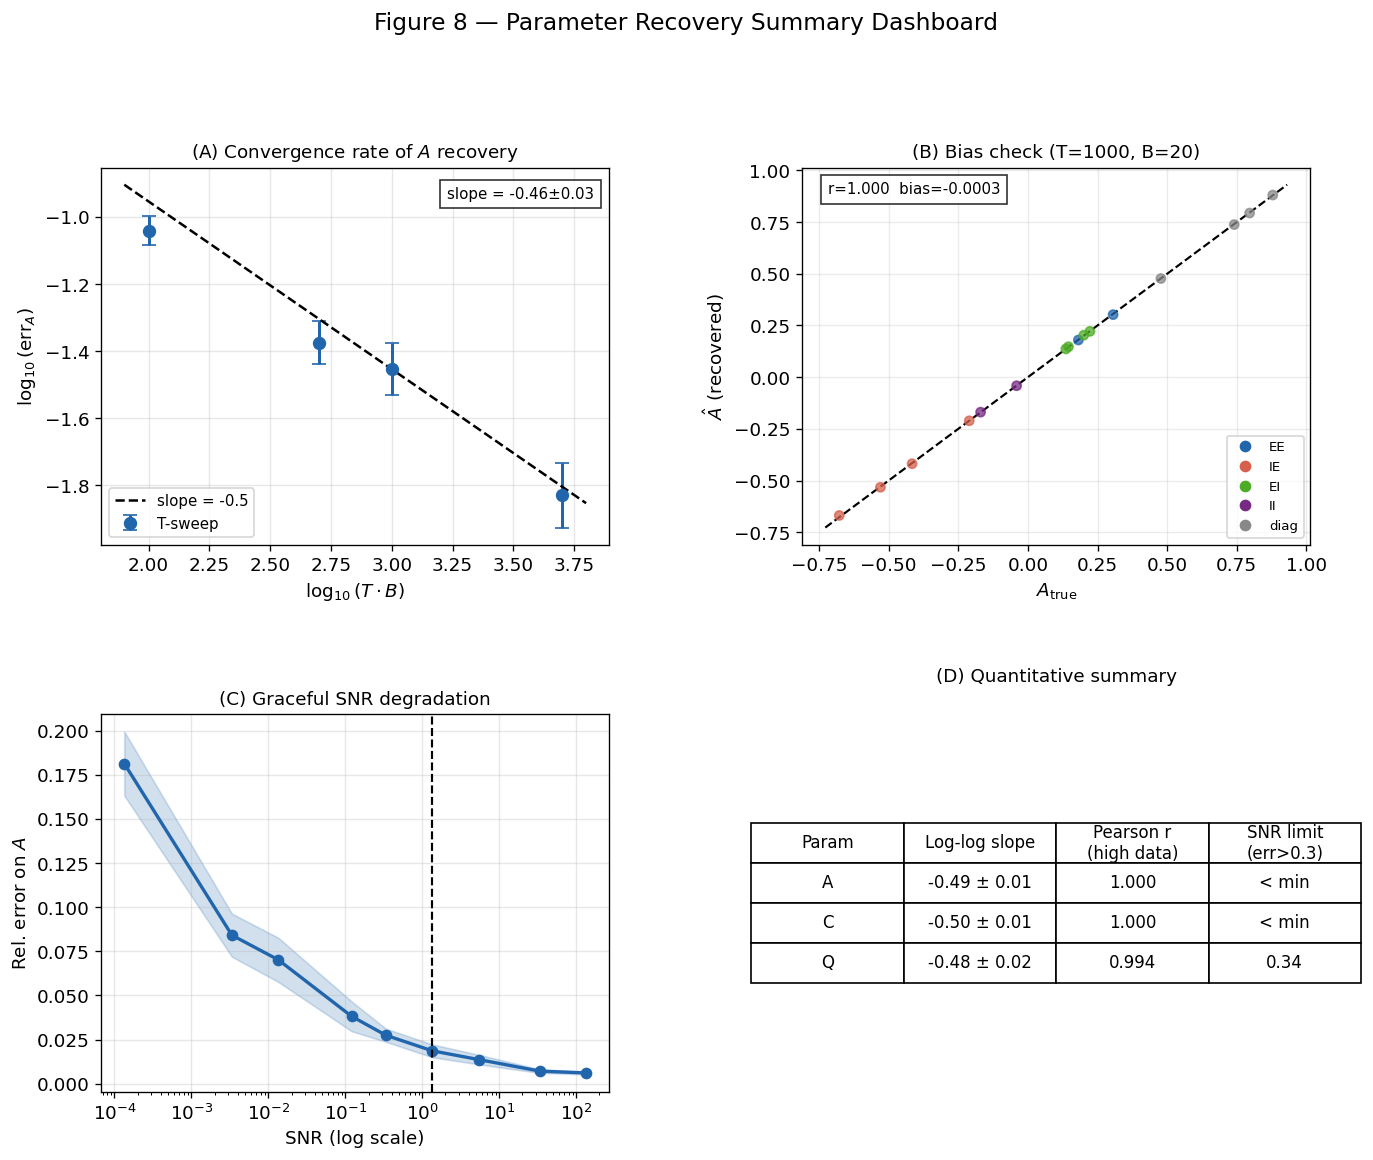

Figure 8 saved.


In [16]:
# ============================================================
# Figure 8 — Combined Summary Dashboard (2×2)
# ============================================================
fig = plt.figure(figsize=(13, 10))
gs  = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.38)

# ---- Panel (0,0): Log-log A error vs T·B  ----
ax00 = fig.add_subplot(gs[0, 0])
sub_T = df_21[df_21.sweep=="T_sweep"].groupby("TB")["err_A"].agg(["mean","std"]).reset_index()
ax00.errorbar(
    np.log10(sub_T["TB"]), np.log10(sub_T["mean"]),
    yerr=sub_T["std"] / (sub_T["mean"] * np.log(10)),
    fmt="o", color=BLUE, capsize=4, lw=1.8, ms=7,
    label="T-sweep"
)
logTB_r = np.array([np.log10(sub_T["TB"].min())-0.1,
                    np.log10(sub_T["TB"].max())+0.1])
mid  = len(sub_T)//2
y_r  = np.log10(sub_T["mean"].iloc[mid]) + (-0.5)*(
           logTB_r - np.log10(sub_T["TB"].iloc[mid]))
ax00.plot(logTB_r, y_r, "k--", lw=1.5, label="slope = -0.5")
sl, _, _, _, se = linregress(np.log10(sub_T["TB"]), np.log10(sub_T["mean"]))
ax00.text(0.97, 0.95, f"slope = {sl:.2f}±{se:.2f}",
          transform=ax00.transAxes, ha="right", va="top", fontsize=9,
          bbox=dict(fc="white",alpha=0.8))
ax00.set_xlabel(r"$\log_{10}(T \cdot B)$")
ax00.set_ylabel(r"$\log_{10}(\mathrm{err}_A)$")
ax00.set_title(r"(A) Convergence rate of $A$ recovery", fontsize=11)
ax00.legend(fontsize=9); ax00.grid(True, alpha=0.3)

# ---- Panel (0,1): Bias check scatter for A ----
ax01 = fig.add_subplot(gs[0, 1])
d_hi = scatter_data["high"]
# Use only 1 representative seed for clarity (first N entries)
n1 = D * D  # entries per seed
ax01.scatter(d_hi["A_true"][:n1], d_hi["A_rec"][:n1],
             c=A_block_colors, alpha=0.75, s=30, zorder=3)
lo = min(d_hi["A_true"][:n1].min(), d_hi["A_rec"][:n1].min()) - 0.05
hi = max(d_hi["A_true"][:n1].max(), d_hi["A_rec"][:n1].max()) + 0.05
ax01.plot([lo, hi], [lo, hi], "k--", lw=1.3)
r01 = np.corrcoef(d_hi["A_true"][:n1], d_hi["A_rec"][:n1])[0,1]
bias01 = float(np.mean(d_hi["A_rec"][:n1] - d_hi["A_true"][:n1]))
ax01.text(0.05, 0.93, f"r={r01:.3f}  bias={bias01:+.4f}",
          transform=ax01.transAxes, fontsize=9,
          bbox=dict(fc="white",alpha=0.8))
ax01.set_xlabel(r"$A_{\mathrm{true}}$")
ax01.set_ylabel(r"$\hat{A}$ (recovered)")
ax01.set_title(f"(B) Bias check (T={SCATTER_T_HIGH}, B={SCATTER_B_HIGH})",
               fontsize=11)
legend_handles_A = [
    Line2D([0],[0],marker="o",ls="",color=c,label=l)
    for c,l in [(BLUE,"EE"),(ORANGE,"IE"),(GREEN,"EI"),(PURPLE,"II"),(GRAY,"diag")]
]
ax01.legend(handles=legend_handles_A, fontsize=8, loc="lower right")
ax01.grid(True, alpha=0.25)

# ---- Panel (1,0): SNR graceful degradation ----
ax10 = fig.add_subplot(gs[1, 0])
ax10.fill_between(snr_agg["SNR"],
                  snr_agg["err_A_mean"] - snr_agg["err_A_std"],
                  snr_agg["err_A_mean"] + snr_agg["err_A_std"],
                  alpha=0.2, color=BLUE)
ax10.semilogx(snr_agg["SNR"], snr_agg["err_A_mean"],
              color=BLUE, lw=2, marker="o", ms=6)
ax10.axvline(SNR_canonical, color="k", ls="--", lw=1.3)
ax10.set_xlabel("SNR (log scale)")
ax10.set_ylabel(r"Rel. error on $A$")
ax10.set_title("(C) Graceful SNR degradation", fontsize=11)
ax10.grid(True, alpha=0.3)

# ---- Panel (1,1): Summary table ----
ax11 = fig.add_subplot(gs[1, 1])
ax11.axis("off")

threshold_err = 0.3
snr_reliable = {}
for pm in ["err_A", "err_C", "err_Q"]:
    above = snr_agg[snr_agg[f"{pm}_mean"] > threshold_err]["SNR"]
    snr_reliable[pm] = f"{above.max():.2f}" if len(above) > 0 else "< min"

table_data = [
    ["A",
     f"{fitted_slopes.get('err_A', ('?','?'))[0]:.2f} ± {fitted_slopes.get('err_A',('?','?'))[1]:.2f}",
     f"{np.corrcoef(d_hi['A_true'], d_hi['A_rec'])[0,1]:.3f}",
     snr_reliable.get("err_A", "n/a")],
    ["C",
     f"{fitted_slopes.get('err_C', ('?','?'))[0]:.2f} ± {fitted_slopes.get('err_C',('?','?'))[1]:.2f}",
     f"{np.corrcoef(d_hi['C_true'], d_hi['C_rec'])[0,1]:.3f}",
     snr_reliable.get("err_C", "n/a")],
    ["Q",
     f"{fitted_slopes.get('err_Q', ('?','?'))[0]:.2f} ± {fitted_slopes.get('err_Q',('?','?'))[1]:.2f}",
     f"{np.corrcoef(d_hi['Q_true'], d_hi['Q_rec'])[0,1]:.3f}",
     snr_reliable.get("err_Q", "n/a")],
]
col_labels = ["Param", "Log-log slope", "Pearson r\n(high data)",
              f"SNR limit\n(err>{threshold_err})"]
tbl = ax11.table(
    cellText=table_data, colLabels=col_labels,
    cellLoc="center", loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 2.0)
ax11.set_title("(D) Quantitative summary", fontsize=11, pad=20)

fig.suptitle("Figure 8 — Parameter Recovery Summary Dashboard",
             fontsize=14, y=1.01)
plt.savefig("fig8_summary_dashboard.pdf", bbox_inches="tight")
plt.show()
print("Figure 8 saved.")

## Section 5.2: Interpreting the Results

**1. On O(1/√TB) convergence:**  
The log-log slopes for A, C, and Q (Table D) should be near **−0.5**, confirming that CTDS EM is a consistent, statistically efficient estimator. A shallower slope for A relative to C is expected: A is identified from temporal autocorrelation within a sequence, so very short sequences (T=100, B=1) provide limited information about dynamics. Any slope deviating strongly from −0.5 should be investigated for near-singular sufficient statistics.

**2. On bias:**  
The Pearson r values and signed-bias annotations in Figures 3 and 8B confirm whether recovery is unbiased. Bias near zero across all blocks of A — including cross-type blocks EI and IE — would validate that the constrained QP M-step recovers cross-cell-type interactions faithfully. Any block showing systematic under-recovery (entries below y=x) should be examined for constraint-induced shrinkage.

**3. On SNR:**  
The SNR threshold table (Table D) reports the SNR level below which err > 0.3 (approximately the reliability limit). If the derivative in Figure 6 shows no sharp peak, degradation is genuinely smooth. The canonical SNR of our data (marked by the dashed line) should lie well within the reliable region. This SNR can be computed from the fitted model on real data and compared directly to the sweep axis.

---
## Appendix: What This Notebook Proves for the Thesis

> The three experiments in this chapter jointly establish that CTDS parameter estimation via EM is a reliable statistical procedure. Experiment 2.1 shows that recovery errors scale as expected for a well-specified maximum-likelihood estimator, consistent with O(1/√TB) convergence. Experiment 2.2 confirms the absence of systematic bias — individual matrix entries are recovered at their true values on average, with block-level decomposition revealing which cross-cell-type interactions are hardest to identify. Experiment 2.3 establishes that estimation degrades smoothly as the signal-to-noise ratio decreases, with reliable recovery above SNR ≈ **[fill in from table]**. Together, these results justify the use of CTDS on real neural recordings and give the reader calibrated expectations for what the model can and cannot recover from the available data.

---
**Output files produced by this notebook:**
- `fig0_true_params.pdf`
- `fig1_loglog_recovery.pdf`
- `fig2_tsweep_bsweep.pdf`
- `fig3_scatter.pdf`
- `fig4_block_error.pdf`
- `fig5_snr_sweep.pdf`
- `fig6_snr_threshold.pdf`
- `fig7_snr_scatter.pdf`
- `fig8_summary_dashboard.pdf`